<a href="https://colab.research.google.com/github/JustmeLu/Tareas-automatizacionInicial/blob/main/2-Ejercicios/05-kNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/andres-merino/AprendizajeAutomaticoInicial-05-N0105/blob/main/2-Ejercicios/05-kNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="border: none; border-collapse: collapse;">
    <tr>
        <td style="width: 20%; vertical-align: middle; padding-right: 10px;">
            <img src="https://i.imgur.com/nt7hloA.png" width="100">
        </td>
        <td style="width: 2px; text-align: center;">
            <font color="#0030A1" size="7">|</font><br>
            <font color="#0030A1" size="7">|</font>
        </td>
        <td>
            <p style="font-variant: small-caps;"><font color="#0030A1" size="5">
                <b>Facultad de Ciencias Exactas, Naturales y Ambientales</b>
            </font> </p>
            <p style="font-variant: small-caps;"><font color="#0030A1" size="4">
                Aprendizaje Automático Inicial &bull; Algoritmo k-Nearest Neighbors
            </font></p>
            <p style="font-style: oblique;"><font color="#0030A1" size="3">
                Luisa Guerrero &bull; 2025-04
            </font></p>
        </td>  
    </tr>
</table>

---
## <font color='264CC7'> Introducción </font>

A lo largo de este taller, aplicaremos el algoritmo de clasificación k-Nearest Neighbors (kNN) para predecir la clase de un conjunto de datos y también para predecir valores numéricos.

Los paquetes necesarios son:

In [43]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score






---
## <font color='264CC7'> Clasificación </font>


### <font color='264CC7'> Preprocesamiento de datos </font>

Primero necesitas el conjunto de datos. Los datos a utilzar son los seleccionados en la clase aterior.

<div style="background-color: #edf1f8; border-color: #264CC7; border-left: 5px solid #264CC7; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Carga el conjunto de datos y procésalos:
<ul>
  <li>Muestra algunos datos.</li>
  <li>Muestra una descripción de los datos.</li>
  <li>Escala los datos si es necesario.</li>
</ul>
</div>

In [3]:
data = pd.read_csv("drug200.csv")

# Mostrar los primeros registros
display(data.head())


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [4]:
data.describe()


,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [5]:
# One-Hot Encoding
data_encoded = pd.get_dummies(
    data,
    columns=['Sex', 'BP', 'Cholesterol'],
    drop_first=True
)

# Mostrar datos codificados
display(data_encoded.head())


,Age,Na_to_K,Drug,Sex_M,BP_LOW,BP_NORMAL,Cholesterol_NORMAL
0,23,25.355,DrugY,False,False,False,False
1,47,13.093,drugC,True,True,False,False
2,47,10.114,drugC,True,True,False,False
3,28,7.798,drugX,False,False,True,False
4,61,18.043,DrugY,False,True,False,False


In [6]:
X = data_encoded.drop('Drug', axis=1)
y = data_encoded['Drug']


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



### <font color='264CC7'> Determinación del valor de k </font>

<div style="background-color: #edf1f8; border-color: #264CC7; border-left: 5px solid #264CC7; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Determina el número óptimo de k para el algoritmo kNN:
<ul>
  <li>Genera una gráfica que muestre el valor de k vs la precisión del modelo.</li>
  <li>Selecciona el valor de k que maximice la precisión.</li>
</ul>
</div>


In [9]:
# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [11]:
k_values = range(1, 21)

precisions_test = []
precisions_train = []

for k in k_values:
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_train, y_train)

    y_pred_test = modelo.predict(X_test)
    y_pred_train = modelo.predict(X_train)

    precisions_test.append(accuracy_score(y_test, y_pred_test))
    precisions_train.append(accuracy_score(y_train, y_pred_train))

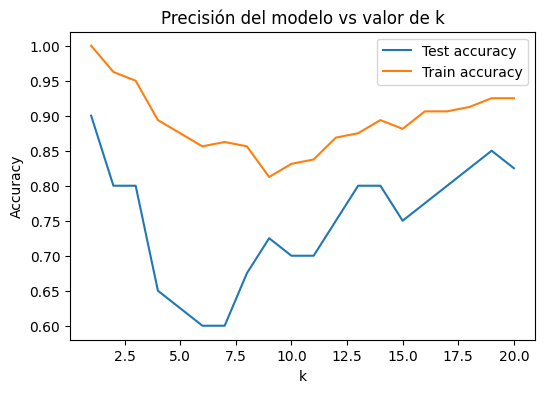

In [13]:
plt.figure(figsize=(6, 4))
plt.plot(k_values, precisions_test, label="Test accuracy")
plt.plot(k_values, precisions_train, label="Train accuracy")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Precisión del modelo vs valor de k")
plt.legend()
plt.show()

Se ha decidido usar k=19  porque tiene la mayor accuracy en este conjunto de de prueba y asi evitar el sobreajsute al elegir un valor pequeño de k


### <font color='264CC7'> Entrenamiento del modelo y evaluación </font>


<div style="background-color: #edf1f8; border-color: #264CC7; border-left: 5px solid #264CC7; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Entrena el modelo y evalúalo:
<ul>
  <li>Entrena el modelo con el valor de k seleccionado.</li>
  <li>Evalúa el modelo con el conjunto de datos de prueba.</li>
  <li>Genera una matriz de confusión y muestra las métricas de evaluación.</li>
</ul>
</div>

In [17]:
# Entrenar el modelo final con k = 19
modelo_final = KNeighborsClassifier(n_neighbors=19)
modelo_final.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=19)

In [18]:

# Predicciones
y_pred = modelo_final.predict(X_test)

# Precisión del modelo
accuracy = round(accuracy_score(y_test, y_pred), 2)
print("Precisión del modelo:", accuracy)


Precisión del modelo: 0.85


In [19]:
cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:")
print(cm)

Matriz de confusión:
[[15  0  0  0  3]
 [ 2  3  0  0  0]
 [ 0  0  3  0  0]
 [ 0  0  0  3  0]
 [ 1  0  0  0 10]]


In [25]:
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))

Reporte de clasificación:
              precision    recall  f1-score   support

       DrugY       0.83      0.83      0.83        18
       drugA       1.00      0.60      0.75         5
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         3
       drugX       0.77      0.91      0.83        11

    accuracy                           0.85        40
   macro avg       0.92      0.87      0.88        40
weighted avg       0.86      0.85      0.85        40



El modelo con k = 19 obtuvo un accuracy del 85 % en el conjunto de prueba.
La matriz de confusión y el reporte de clasificación se ve bastante bien en general, con clasificación perfecta para algunas clases


---
## <font color='264CC7'> Regresión </font>


### <font color='264CC7'> Preprocesamiento de datos </font>

Primero necesitas el conjunto de datos. Los datos a utilzar son los seleccionados en la clase aterior.

<div style="background-color: #edf1f8; border-color: #264CC7; border-left: 5px solid #264CC7; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Carga el conjunto de datos y procésalos:
<ul>
  <li>Muestra algunos datos.</li>
  <li>Muestra una descripción de los datos.</li>
  <li>Escala los datos si es necesario.</li>
</ul>
</div>

In [26]:
# Cargar dataset
data = pd.read_csv("drug200.csv")

# Mostrar los primeros registros
display(data.head())

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [28]:
data.describe()


,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [29]:
data_encoded = pd.get_dummies(
    data,
    columns=['Sex', 'BP', 'Cholesterol'],
    drop_first=True
)

display(data_encoded.head())


,Age,Na_to_K,Drug,Sex_M,BP_LOW,BP_NORMAL,Cholesterol_NORMAL
0,23,25.355,DrugY,False,False,False,False
1,47,13.093,drugC,True,True,False,False
2,47,10.114,drugC,True,True,False,False
3,28,7.798,drugX,False,False,True,False
4,61,18.043,DrugY,False,True,False,False


In [31]:
y = data_encoded['Na_to_K']
X = data_encoded.drop(['Na_to_K', 'Drug'], axis=1)


In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### <font color='264CC7'> Determinación del valor de k </font>

<div style="background-color: #edf1f8; border-color: #264CC7; border-left: 5px solid #264CC7; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Determina el número óptimo de k para el algoritmo kNN:
<ul>
  <li>Genera una gráfica que muestre el valor de k vs la precisión del modelo.</li>
  <li>Selecciona el valor de k que maximice la precisión.</li>
</ul>
</div>


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
k_values = range(1, 21)
r2_scores = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)

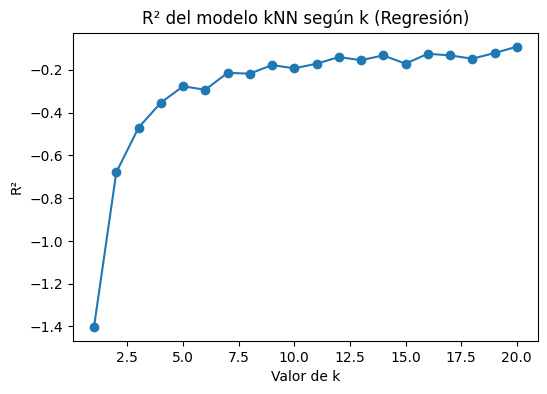

In [42]:
plt.figure(figsize=(6,4))
plt.plot(k_values, r2_scores, marker='o')
plt.xlabel("Valor de k")
plt.ylabel("R²")
plt.title("R² del modelo kNN según k (Regresión)")
plt.show()

A pesar de optimizar el valor de k el modelo kNN de regresión tiene valores negativos de R cuadrado, tiene un bajo poder explicativo y queire decir que este algoritmo no es el mejor para modelar la variable continua seleccionada.


### <font color='264CC7'> Entrenamiento del modelo y evaluación </font>


<div style="background-color: #edf1f8; border-color: #264CC7; border-left: 5px solid #264CC7; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Entrena el modelo y evalúalo:
<ul>
  <li>Entrena el modelo con el valor de k seleccionado.</li>
  <li>Evalúa el modelo con el conjunto de datos de prueba.</li>
  <li>Calcula el error cuadrático medio.</li>
</ul>
</div>

In [44]:
k_optimo = 20

knn_reg = KNeighborsRegressor(n_neighbors=k_optimo)
knn_reg.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=20)

In [45]:
# Predicciones
y_pred = knn_reg.predict(X_test)


In [46]:
# Error Cuadrático Medio
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("Error Cuadrático Medio (MSE):", round(mse, 3))
print("Raíz del Error Cuadrático Medio (RMSE):", round(rmse, 3))
print("R² del modelo:", round(r2, 3))


Error Cuadrático Medio (MSE): 54.782
Raíz del Error Cuadrático Medio (RMSE): 7.401
R² del modelo: -0.092


El modelo kNN de regresión fue entrenado con el valor óptimo de k segun la grafica, pero el valor negativo del coeficiente R² y el RMSE obtenido indican que el modelo tiene un bajo poder predictivo entonces en este caso kNN no es el algoritmo más adecuado para este problema de regresión.

Este algoritmo kNN mostró un buen desempeño en la tarea de clasificación, ya que el conjunto de datos tiene patrones  entre las variables y la clase objetivo, pero su desempeño en regresión fue bajo, entonces kNN no es adecuado para modelar relaciones continuas en este dataset
